# HPC vs SMC — Region Comparison

Reads the CSVs produced by `vascular_graph_analysis.ipynb` for each region and compares them.

**Run `vascular_graph_analysis.ipynb` for both HPC and SMC before running this notebook.**

---
**Sections:**
1. [Configuration & data loading](#1-configuration--data-loading)
2. [Helper functions & plot style](#2-helper-functions--plot-style)
3. [Vessel density](#3-vessel-density)
4. [Diameter & length by vessel type](#4-diameter--length-by-vessel-type)
5. [Boundary conditions](#5-boundary-conditions)
6. [Connectivity — min-cut & redundancy](#6-connectivity--min-cut--redundancy)
7. [Saturation](#7-saturation)
8. [Major tree coverage](#8-major-tree-coverage)
9. [Save all stats](#9-save-all-stats)

---
## 1. Configuration & data loading

In [55]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import ttest_ind

sys.path.insert(0, "/home/ana/MicroBrain/codes/Graph Analysis & by region/Graph analysis")
from graph_analysis_functions_formatted import *

# =====================================================================
# PATHS
# =====================================================================
HPC_DIR = "/home/admin/Ana/MicroBrain/output/HPC_FULL_ANALYSIS_FORMATTED"
SMC_DIR = "/home/admin/Ana/MicroBrain/output/SMC_FULL_ANALYSIS_FORMATTED"
OUT_DIR = "/home/admin/Ana/MicroBrain/output/HPC_vs_SMC_STATS"
os.makedirs(OUT_DIR, exist_ok=True)

# =====================================================================
# COLORS
# Violin fill is light; box + median are dark for clear visibility
# =====================================================================


REGION_COL = {
    "HPC": "#ff7f00",   
    "SMC": "#4daf4a",   
}

REGION_LIGHT = {
    "HPC": "#fdd0a2",   
    "SMC": "#c7e9c0",  
}

TYPE_ORDER   = ("arteriole", "venule", "capillary")
REGION_ORDER = ("HPC", "SMC")

# =====================================================================
# FILE MAP
# =====================================================================
FILE_MAP = {
    "summary":     "{region}_summary.csv",
    "density":     "{region}_density_subboxes.csv",
    "diam_length": "{region}_diameter_length.csv",
    "bc_pooled":   "{region}_bc_pooled.csv",
    "bc_long":     "{region}_bc_diameter_long.csv",
    "saturation":  "{region}_saturation.csv",
    "mincut":      "{region}_mincut.csv",
    "redundancy":  "{region}_redundancy.csv",
}
REGION_DIRS = {"HPC": HPC_DIR, "SMC": SMC_DIR}

def load_both(key, region_col="region"):
    dfs = []
    for region in REGION_ORDER:
        fname = FILE_MAP[key].format(region=region)
        path  = os.path.join(REGION_DIRS[region], fname)
        if os.path.exists(path):
            df = pd.read_csv(path)
            df[region_col] = region
            dfs.append(df)
        else:
            print(f"[WARNING] Not found: {path}")
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# =====================================================================
# LOAD
# =====================================================================
summary     = load_both("summary")
density_all = load_both("density")
dl_all      = load_both("diam_length")
bc_pooled   = load_both("bc_pooled")
bc_long     = load_both("bc_long")
saturation  = load_both("saturation")
mincut      = load_both("mincut")
redundancy  = load_both("redundancy")

for name, df in [("summary", summary), ("density_all", density_all),
                  ("dl_all", dl_all), ("bc_pooled", bc_pooled),
                  ("bc_long", bc_long), ("saturation", saturation),
                  ("mincut", mincut), ("redundancy", redundancy)]:
    print(f"{name:15s}: {df.shape}")

summary        : (6, 69)
density_all    : (8232, 5)
dl_all         : (7998, 5)
bc_pooled      : (17, 9)
bc_long        : (1962, 6)
saturation     : (9, 20)
mincut         : (6, 11)
redundancy     : (6, 11)


---
## 2. Helper functions & plot style

In [56]:
# =====================================================================
# STATS
# =====================================================================
def _finite(x):
    x = np.asarray(x, float)
    return x[np.isfinite(x)]

def _normalize_types(df, col="type"):
    d = df.copy()
    d[col] = d[col].astype(str).str.lower().str.strip()
    d[col] = d[col].replace({
        "artery": "arteriole", "arterial": "arteriole",
        "vein": "venule",      "venous": "venule",
        "cap": "capillary",
    })
    return d


def _p_to_text(p):
    if not np.isfinite(p):
        return "p=NA"
    if p < 1e-4:
        return "p<1e-4"
    elif p < 1e-3:
        return "p<0.001"
    elif p < 1e-2:
        return "p<0.01"
    elif p < 0.05:
        return "p<0.05"
    else:
        return f"ns (p={p:.2f})"

def welch_row(x1, x2, label, extra=None):
    x1, x2 = _finite(x1), _finite(x2)
    if x1.size < 2 or x2.size < 2:
        t_stat, p_val = np.nan, np.nan
    else:
        t_stat, p_val = ttest_ind(x1, x2, equal_var=False, nan_policy="omit")
    row = {
        "metric":     label,
        "HPC_n":      int(x1.size),
        "SMC_n":      int(x2.size),
        "HPC_mean":   float(np.mean(x1))   if x1.size else np.nan,
        "SMC_mean":   float(np.mean(x2))   if x2.size else np.nan,
        "HPC_median": float(np.median(x1)) if x1.size else np.nan,
        "SMC_median": float(np.median(x2)) if x2.size else np.nan,
        "t_stat":     float(t_stat) if np.isfinite(t_stat) else np.nan,
        "p_value":    float(p_val)  if np.isfinite(p_val)  else np.nan,
    }
    if extra: row.update(extra)
    return row

# =====================================================================
# CORE DRAWING — violin (light fill) + narrow box (dark) 
# The median line is WHITE on the dark box so it's always visible
# =====================================================================
def _draw_violin_box(ax, data_hpc, data_smc, clip_pct=98):
    all_vals = np.concatenate([data_hpc, data_smc])
    y_clip   = float(np.percentile(all_vals, clip_pct))
    y_min    = max(0.0, float(np.percentile(all_vals, 1)))

    hpc_c = np.clip(data_hpc, y_min, y_clip)
    smc_c = np.clip(data_smc, y_min, y_clip)

    # violin — light fill, colored edge
    vp = ax.violinplot([hpc_c, smc_c], positions=[1, 2],
                        widths=0.72, showmeans=False, showmedians=False, showextrema=False)
    for body, lab in zip(vp["bodies"], ["HPC", "SMC"]):
        body.set_facecolor(REGION_LIGHT[lab])
        body.set_edgecolor(REGION_COL[lab])
        body.set_linewidth(1.0)
        body.set_alpha(0.9)

    # narrow box — dark fill, white median line
    bp = ax.boxplot(
        [hpc_c, smc_c], positions=[1, 2], widths=0.13,
        showfliers=False, patch_artist=True,
        medianprops=dict(color="white", linewidth=2.8, solid_capstyle="round"),
        whiskerprops=dict(color="#444444", linewidth=1.1),
        capprops=dict(color="#444444", linewidth=1.1),
        boxprops=dict(linewidth=0)
    )
    for patch, lab in zip(bp["boxes"], ["HPC", "SMC"]):
        patch.set_facecolor(REGION_COL[lab])
        patch.set_alpha(0.92)

    return y_clip, y_min


def _add_pvalue(ax, p, y_clip, y_min):
    span  = max(y_clip - y_min, 1e-10)
    y_bar = y_clip + span * 0.10
    h     = span * 0.03
    ax.plot([1, 1, 2, 2], [y_bar, y_bar+h, y_bar+h, y_bar], lw=1.0, c="#333333")
    ax.text(1.5, y_bar + h + span*0.015, _p_to_text(p),
            ha="center", va="bottom", fontsize=9, color="#333333")
    ax.set_ylim(y_min - span*0.05, y_bar + h + span*0.22)


def _style_ax(ax, ylabel):
    ax.set_xticks([1, 2])
    ax.set_xticklabels(["HPC", "SMC"], fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(alpha=0.15, axis="y", linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def _legend(fig):
    handles = [
        mpatches.Patch(
            facecolor=REGION_LIGHT[r],
            edgecolor=REGION_COL[r],
            linewidth=1.3,
            label=r
        )
        for r in REGION_ORDER 
    ]
    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.91),   
        ncol=len(REGION_ORDER),
        frameon=False,
        fontsize=10
    )


# =====================================================================
# PUBLIC PLOT FUNCTIONS
# =====================================================================
def plot_region_metric(df, value_col, ylabel, title, out_path=None, clip_pct=98):
    """Single panel: HPC vs SMC for one metric."""
    hpc = _finite(df.loc[df["region"]=="HPC", value_col].to_numpy(float))
    smc = _finite(df.loc[df["region"]=="SMC", value_col].to_numpy(float))
    if hpc.size == 0 or smc.size == 0:
        print(f"[skip] {value_col}"); return pd.DataFrame()

    stat_row = welch_row(hpc, smc, value_col)

    fig, ax = plt.subplots(figsize=(4.5, 5.0))
    y_clip, y_min = _draw_violin_box(ax, hpc, smc, clip_pct=clip_pct)
    _add_pvalue(ax, stat_row["p_value"], y_clip, y_min)
    _style_ax(ax, ylabel)
    fig.suptitle(title, fontsize=12, y=0.98)
    _legend(fig)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    if out_path: plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return pd.DataFrame([stat_row])


def plot_region_by_type(df, value_col, ylabel, title,
                         type_col="type", out_path=None, clip_pct=98):
    """One panel per vessel type: HPC vs SMC."""
    df = _normalize_types(df, col=type_col)
    types_present = [t for t in TYPE_ORDER if t in df[type_col].unique()]
    if not types_present:
        print(f"[skip] {value_col}"); return pd.DataFrame()

    fig, axes = plt.subplots(1, len(types_present),
                              figsize=(4.5*len(types_present), 5.2), sharey=False)
    if len(types_present) == 1: axes = [axes]

    stats_rows = []
    for ax, t in zip(axes, types_present):
        sub = df[df[type_col] == t]
        hpc = _finite(sub.loc[sub["region"]=="HPC", value_col].to_numpy(float))
        smc = _finite(sub.loc[sub["region"]=="SMC", value_col].to_numpy(float))
        if hpc.size == 0 or smc.size == 0:
            ax.set_axis_off(); continue

        stat_row = welch_row(hpc, smc, value_col, extra={"type": t})
        stats_rows.append(stat_row)

        y_clip, y_min = _draw_violin_box(ax, hpc, smc, clip_pct=clip_pct)
        _add_pvalue(ax, stat_row["p_value"], y_clip, y_min)
        _style_ax(ax, ylabel)
        ax.set_title(t, fontsize=12)

    fig.suptitle(title, fontsize=13, y=0.98)
    _legend(fig)
    plt.tight_layout(rect=[0, 0, 1, 0.84])
    if out_path: plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(stats_rows)


def plot_bc_kind_distribution(bc_pooled_all, out_path=None):
    """Grouped bar+scatter: boundary-face vessel type % — HPC vs SMC."""
    df = bc_pooled_all.copy()
    if "type" in df.columns and "vessel_type" not in df.columns:
        df = df.rename(columns={"type": "vessel_type"})
    df = _normalize_types(df, col="vessel_type")

    fig, ax = plt.subplots(figsize=(7.0, 4.8))
    x       = np.arange(len(TYPE_ORDER), dtype=float)
    width   = 0.32
    offsets = {"HPC": -width/2, "SMC": width/2}
    stats_rows = []
    rng = np.random.default_rng(42)

    for i, vt in enumerate(TYPE_ORDER):
        sub = df[df["vessel_type"] == vt]
        hpc = _finite(sub.loc[sub["region"]=="HPC", "pct"].to_numpy(float))
        smc = _finite(sub.loc[sub["region"]=="SMC", "pct"].to_numpy(float))

        for lab, vals in [("HPC", hpc), ("SMC", smc)]:
            if vals.size:
                ax.bar(x[i]+offsets[lab], np.mean(vals), width=width,
                       color=REGION_LIGHT[lab], edgecolor=REGION_COL[lab],
                       linewidth=1.3, zorder=2)
                xj = np.full(vals.size, x[i]+offsets[lab]) + rng.uniform(-0.04, 0.04, vals.size)
                ax.scatter(xj, vals, s=40, color=REGION_COL[lab],
                           alpha=0.85, zorder=3, edgecolors="white", linewidths=0.5)

        row = welch_row(hpc, smc, "BC_pct", extra={"vessel_type": vt})
        stats_rows.append(row)
        if hpc.size and smc.size:
            y_top = max(np.max(hpc), np.max(smc))
            y0, y1 = ax.get_ylim()
            yr = max(y1 - y0, 1.0)
            y_bar = y_top + yr * 0.04
            h     = yr * 0.025
            ax.plot([x[i]+offsets["HPC"], x[i]+offsets["HPC"],
                     x[i]+offsets["SMC"], x[i]+offsets["SMC"]],
                    [y_bar, y_bar+h, y_bar+h, y_bar], lw=0.9, c="#333333")
            ax.text(x[i], y_bar+h+yr*0.008, _p_to_text(row["p_value"]),
                    ha="center", va="bottom", fontsize=8.5, color="#333333")

    ax.set_xticks(x)
    ax.set_xticklabels(TYPE_ORDER, fontsize=12)
    ax.set_ylabel("Boundary-face composition (%)", fontsize=11)
    ax.set_title("Boundary-face vessel type distribution | HPC vs SMC", fontsize=12)
    ax.grid(alpha=0.15, axis="y", linestyle="--")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    handles = [mpatches.Patch(facecolor=REGION_LIGHT[r], edgecolor=REGION_COL[r],
                               linewidth=1.3, label=r) for r in REGION_ORDER]
    ax.legend(handles=handles, frameon=False, fontsize=10)
    plt.tight_layout()
    if out_path: plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    return pd.DataFrame(stats_rows)


print("Plot functions ready.")

Plot functions ready.


---
## 3. Vessel density

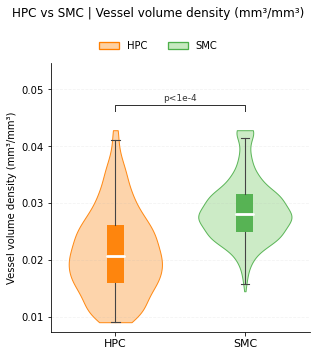

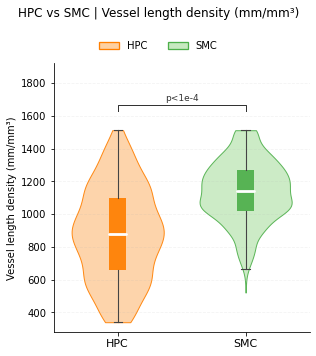

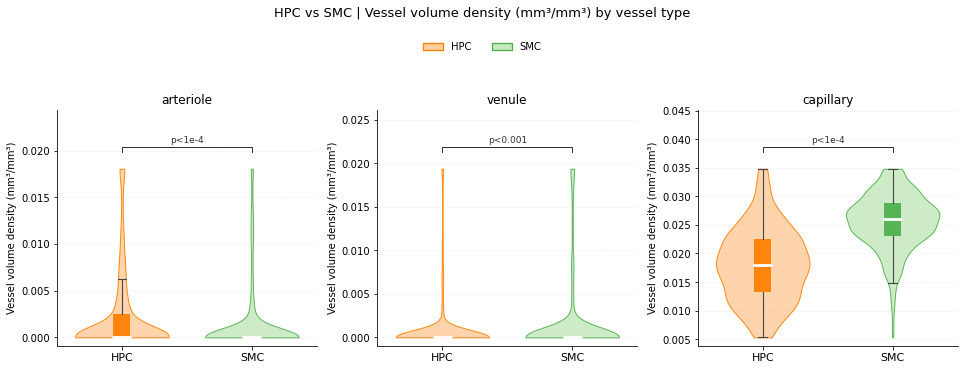

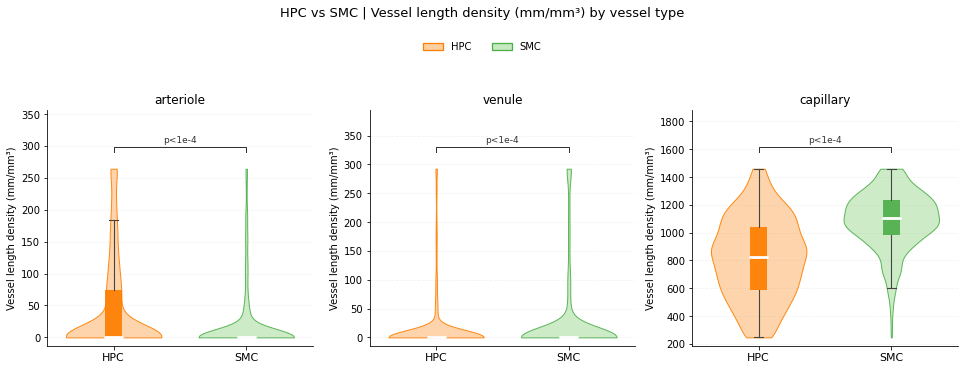

In [57]:
all_stats = []

if not density_all.empty:
    df_total = density_all[density_all["type"] == "total"]

    for col, label in [
        ("vessel_volume_density", "Vessel volume density (mm³/mm³)"),
        ("vessel_length_density", "Vessel length density (mm/mm³)"),
    ]:
        st = plot_region_metric(
            df_total, col, label, f"HPC vs SMC | {label}",
            out_path=os.path.join(OUT_DIR, f"HPC_vs_SMC_{col}_total.png"))
        if not st.empty: all_stats.append(st)

    for col, label in [
        ("vessel_volume_density", "Vessel volume density (mm³/mm³)"),
        ("vessel_length_density", "Vessel length density (mm/mm³)"),
    ]:
        st = plot_region_by_type(
            density_all, col, label, f"HPC vs SMC | {label} by vessel type",
            out_path=os.path.join(OUT_DIR, f"HPC_vs_SMC_{col}_by_type.png"))
        if not st.empty: all_stats.append(st)

---
## 4. Diameter & length by vessel type

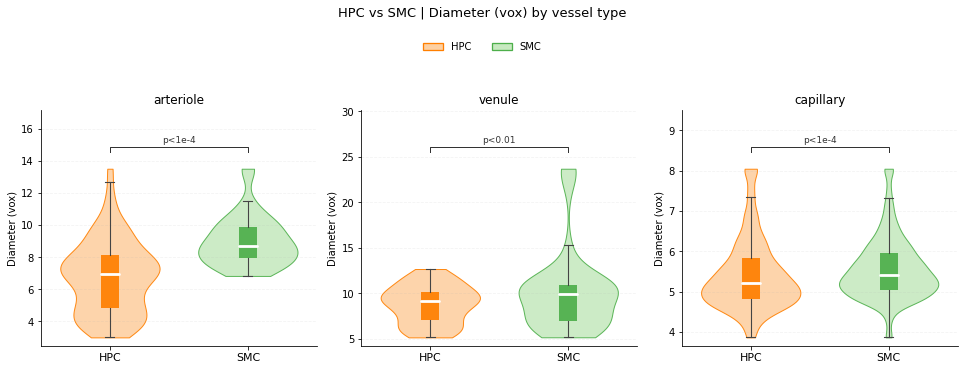

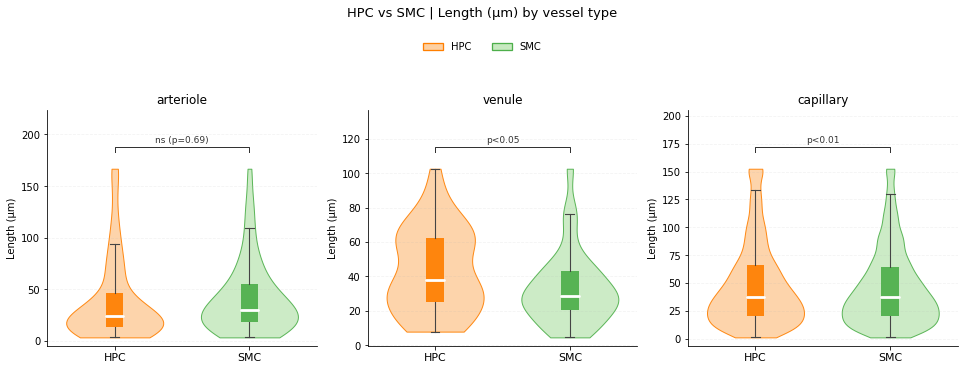

In [58]:
if not dl_all.empty:
    dl_all = _normalize_types(dl_all, col="type")

    for col, label in [
        ("diameter_vox", "Diameter (vox)"),
        ("length_um",    "Length (µm)"),
    ]:
        st = plot_region_by_type(
            dl_all, col, label, f"HPC vs SMC | {label} by vessel type",
            out_path=os.path.join(OUT_DIR, f"HPC_vs_SMC_{col}_by_type.png"))
        if not st.empty: all_stats.append(st)

---
## 5. Boundary conditions

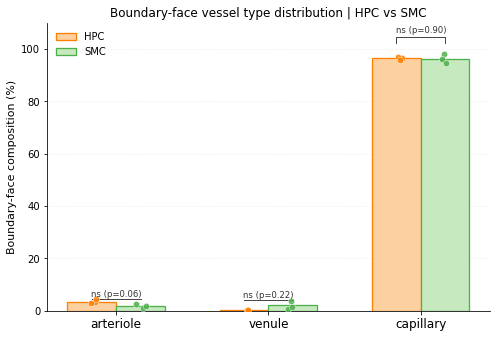

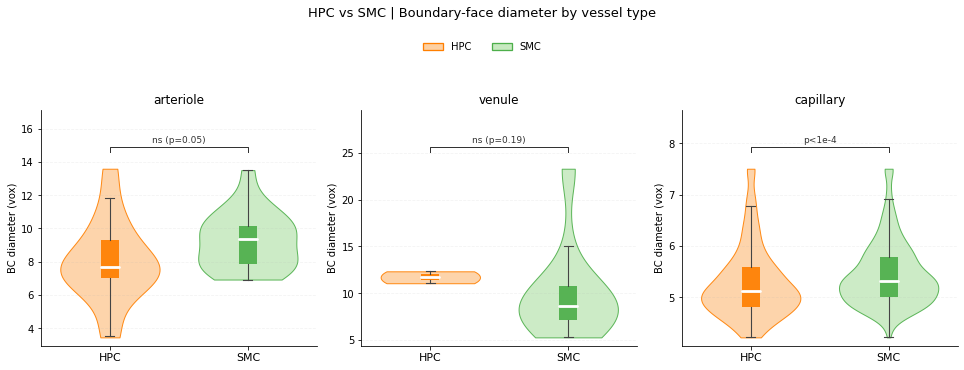

In [59]:
if not bc_pooled.empty:
    st = plot_bc_kind_distribution(
        bc_pooled,
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_BC_kind_distribution.png"))
    if not st.empty: all_stats.append(st)

if not bc_long.empty:
    bc_long_norm = bc_long.copy()
    if "vessel_type" in bc_long_norm.columns and "type" not in bc_long_norm.columns:
        bc_long_norm = bc_long_norm.rename(columns={"vessel_type": "type"})
    bc_long_norm = _normalize_types(bc_long_norm, col="type")

    st = plot_region_by_type(
        bc_long_norm, "diameter", "BC diameter (vox)",
        "HPC vs SMC | Boundary-face diameter by vessel type",
        out_path=os.path.join(OUT_DIR, "HPC_vs_SMC_BC_diameter_by_type.png"))
    if not st.empty: all_stats.append(st)
else:
    print("[skip] BC long diameter — files not found.")

---
## 6. Connectivity — min-cut & redundancy

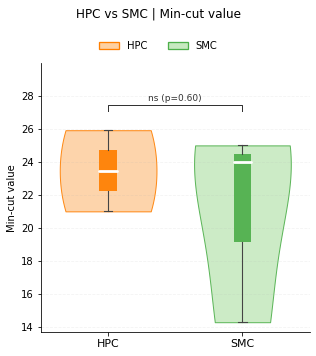

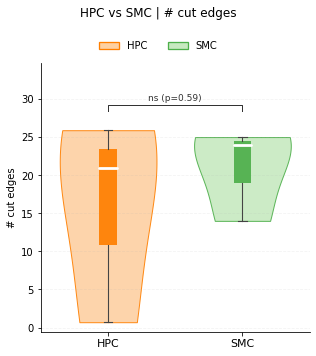

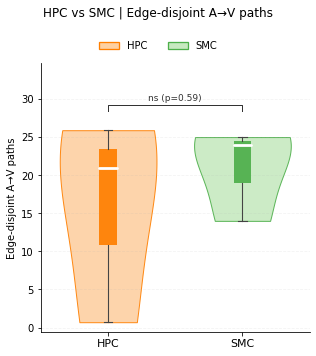

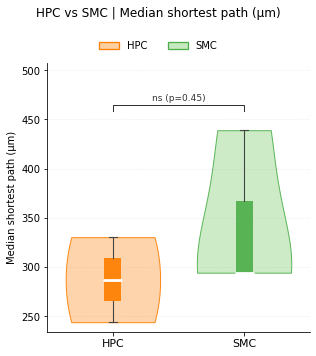

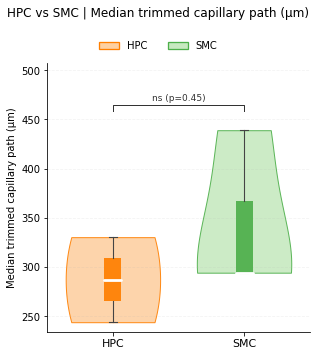

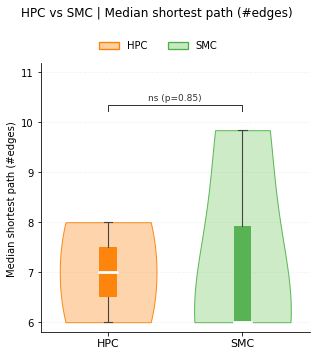

In [67]:
if not mincut.empty:
    for col, label in [
        ("min_cut_value", "Min-cut value"),
        ("n_cut_edges",   "# cut edges"),
    ]:
        if col in mincut.columns:
            st = plot_region_metric(
                mincut, col, label, f"HPC vs SMC | {label}",
                out_path=os.path.join(OUT_DIR, f"HPC_vs_SMC_{col}.png"))
            if not st.empty: all_stats.append(st)

if not redundancy.empty:
    for col, label in [
        ("edge_disjoint_AV",               "Edge-disjoint A→V paths"),
        ("shortest_path_len_median_um",    "Median shortest path (µm)"),
        ("trimmed_capillary_len_median_um", "Median trimmed capillary path (µm)"),
        ("shortest_path_len_median_edges",  "Median shortest path (#edges) "),
    ]:
        if col in redundancy.columns:
            st = plot_region_metric(
                redundancy, col, label, f"HPC vs SMC | {label}",
                out_path=os.path.join(OUT_DIR, f"HPC_vs_SMC_{col}.png"))
            if not st.empty: all_stats.append(st)

---
## 7. Saturation

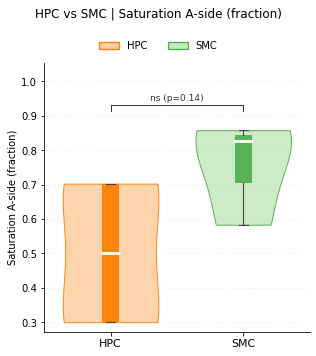

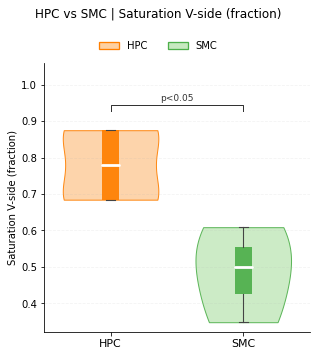

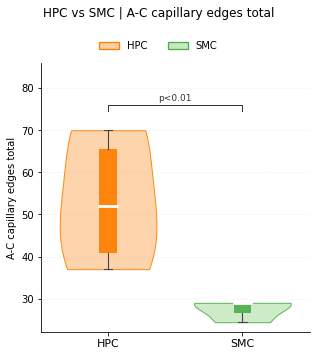

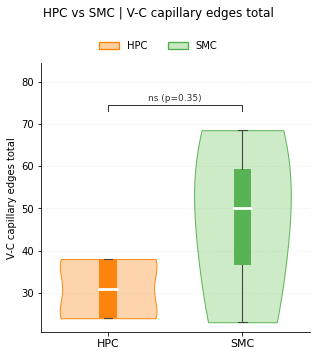

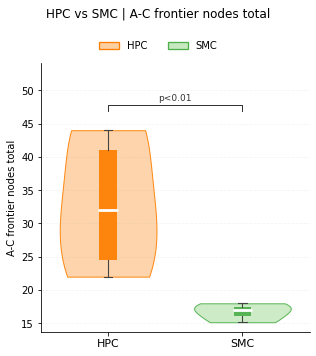

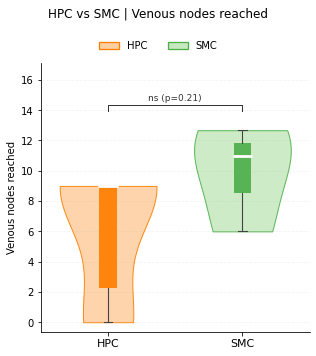

In [61]:
if not saturation.empty:
    for col, label in [
        ("saturation_ac_edges",     "Saturation A-side (fraction)"),
        ("saturation_vc_edges",     "Saturation V-side (fraction)"),
        ("n_ac_cap_edges_total",    "A-C capillary edges total"),
        ("n_vc_cap_edges_total",    "V-C capillary edges total"),
        ("ac_frontier_nodes_total", "A-C frontier nodes total"),
        ("vc_nodes_reached",        "Venous nodes reached"),
    ]:
        if col not in saturation.columns:
            print(f"[skip] {col}"); continue
        st = plot_region_metric(
            saturation, col, label, f"HPC vs SMC | {label}",
            out_path=os.path.join(OUT_DIR, f"HPC_vs_SMC_{col}.png"))
        if not st.empty: all_stats.append(st)

---
## 8. Major tree coverage

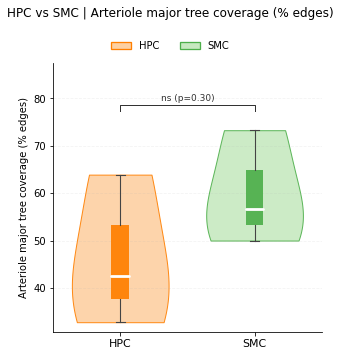

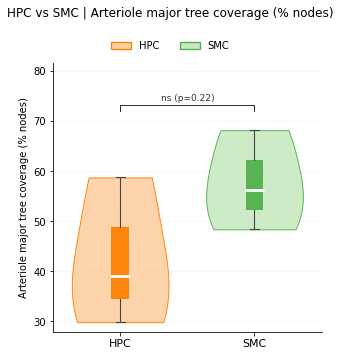

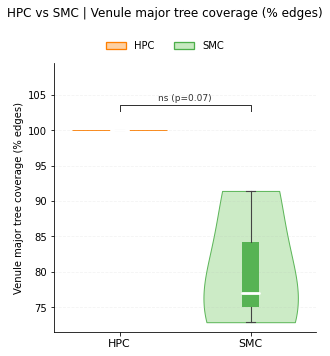

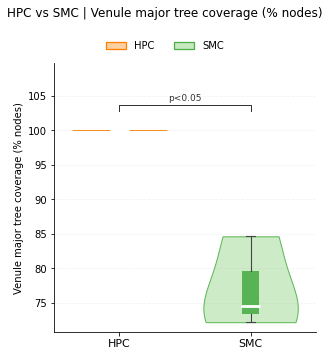

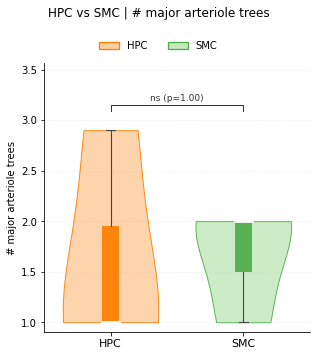

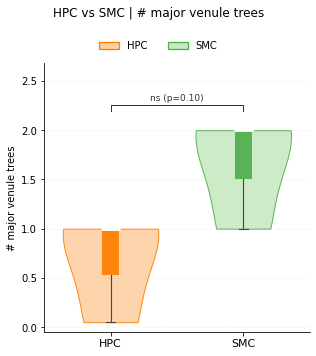

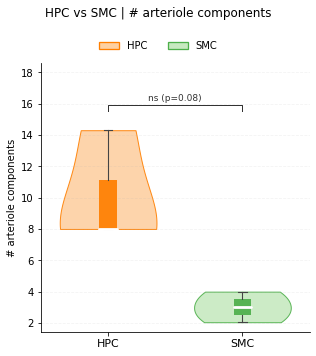

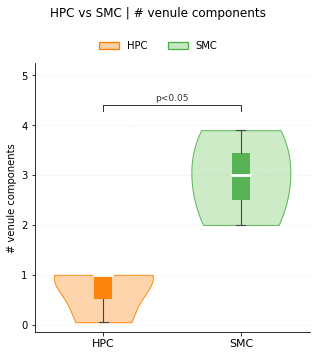

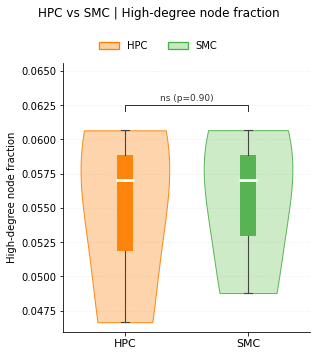

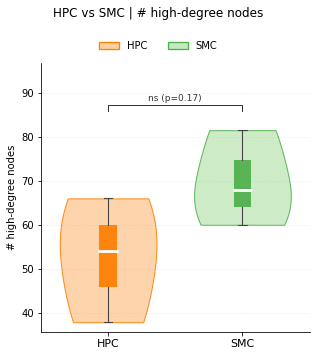

In [62]:
if not summary.empty:
    for col, label in [
        ("art_major1_pct_edges",    "Arteriole major tree coverage (% edges)"),
        ("art_major1_pct_nodes",    "Arteriole major tree coverage (% nodes)"),
        ("ven_major1_pct_edges",    "Venule major tree coverage (% edges)"),
        ("ven_major1_pct_nodes",    "Venule major tree coverage (% nodes)"),
        ("n_major_arteriole_trees", "# major arteriole trees"),
        ("n_major_venule_trees",    "# major venule trees"),
        ("n_arteriole_components",  "# arteriole components"),
        ("n_venule_components",     "# venule components"),
        ("HDN_frac",                "High-degree node fraction"),
        ("HDN_n",                   "# high-degree nodes"),
    ]:
        if col not in summary.columns:
            print(f"[skip] {col}"); continue
        st = plot_region_metric(
            summary, col, label, f"HPC vs SMC | {label}",
            out_path=os.path.join(OUT_DIR, f"HPC_vs_SMC_{col}.png"))
        if not st.empty: all_stats.append(st)

---
## 9. Save all stats

In [63]:
if all_stats:
    df_stats = pd.concat(all_stats, ignore_index=True)
    stats_path = os.path.join(OUT_DIR, "HPC_vs_SMC_all_stats.csv")
    df_stats.to_csv(stats_path, index=False)
    print(f"Saved {len(df_stats)} stat rows → {stats_path}\n")
    display_cols = [c for c in ["metric", "type", "vessel_type",
                                 "HPC_n", "SMC_n", "HPC_median", "SMC_median", "p_value"]
                    if c in df_stats.columns]
    print(df_stats[display_cols].to_string(index=False))
else:
    print("No stats collected.")

print(f"\nAll outputs saved in: {OUT_DIR}")

Saved 41 stat rows → /home/admin/Ana/MicroBrain/output/HPC_vs_SMC_STATS/HPC_vs_SMC_all_stats.csv

                         metric      type vessel_type  HPC_n  SMC_n  HPC_median  SMC_median       p_value
          vessel_volume_density       NaN         NaN   1029   1029    0.020661    0.028059 6.771819e-104
          vessel_length_density       NaN         NaN   1029   1029  877.724394 1141.645553 6.959383e-112
          vessel_volume_density arteriole         NaN   1029   1029    0.000000    0.000000  3.198740e-06
          vessel_volume_density    venule         NaN   1029   1029    0.000000    0.000000  1.092061e-04
          vessel_volume_density capillary         NaN   1029   1029    0.018069    0.026081 4.283196e-154
          vessel_length_density arteriole         NaN   1029   1029    0.000000    0.000000  8.952091e-20
          vessel_length_density    venule         NaN   1029   1029    0.000000    0.000000  9.029986e-05
          vessel_length_density capillary         NaN 